In [1]:
import os
import math

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn

from datasets import load_from_disk, concatenate_datasets
from brainlm_mae.modeling_brainlm import BrainLMForPretraining

/gpfs/gibbs/project/dijk/sr2464/conda_envs/brainlm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if not os.path.exists("inference_plots"):
    os.mkdir("inference_plots")

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Load model

In [4]:
model = BrainLMForPretraining.from_pretrained("pretrained_models/2023-06-24-00_00_00_checkpoint-3000")
model

You are using a model of type brainlm_mae to instantiate a model of type vit_mae. This is not supported for all configurations of models and can yield errors.


BrainLMForPretraining(
  (vit): BrainLMModel(
    (embeddings): BrainLMEmbeddings(
      (patch_embeddings): None
      (signal_embedding_projection): Linear(in_features=49, out_features=512, bias=True)
      (xyz_embedding_projection): Linear(in_features=3, out_features=512, bias=True)
      (pos_embedding): PositionalEncoding(
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (encoder): BrainLMEncoder(
      (layer): ModuleList(
        (0): NystromformerLayer(
          (attention): NystromformerAttention(
            (self): NystromformerSelfAttention(
              (query): Linear(in_features=512, out_features=512, bias=True)
              (key): Linear(in_features=512, out_features=512, bias=True)
              (value): Linear(in_features=512, out_features=512, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              (conv): Conv2d(4, 4, kernel_size=(65, 1), stride=(1, 1), padding=(32, 0), groups=4, bias=False)
            )
            (ou

In [5]:
print(model.vit.config)

ViTMAEConfig {
  "_name_or_path": "pretrained_models/2023-06-24-00_00_00_checkpoint-3000",
  "architectures": [
    "BrainLMForPretraining"
  ],
  "attention_probs_dropout_prob": 0.1,
  "conv_kernel_size": 65,
  "decoder_hidden_size": 512,
  "decoder_intermediate_size": 1024,
  "decoder_num_attention_heads": 4,
  "decoder_num_hidden_layers": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 512,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 1024,
  "inv_coeff_init_option": false,
  "layer_norm_eps": 1e-12,
  "loss_fn": "mse",
  "mask_ratio": 0.6,
  "model_type": "vit_mae",
  "norm_pix_loss": false,
  "num_attention_heads": 4,
  "num_brain_voxels": 424,
  "num_channels": 3,
  "num_hidden_layers": 4,
  "num_landmarks": 64,
  "num_timepoints_per_voxel": 490,
  "patch_size": 16,
  "qkv_bias": true,
  "segment_means_seq_len": 64,
  "timepoint_patching_size": 49,
  "torch_dtype": "float32",
  "transformers_version": "4.28.0.dev0",
  "use_tan

In [8]:
print(model.vit.embeddings.mask_ratio)
print(model.vit.embeddings.config.mask_ratio)

0.0
0.0


In [7]:
model.vit.embeddings.mask_ratio = 0.0
model.vit.embeddings.config.mask_ratio = 0.0

## Load Entire Dataset

In [9]:
train_ds = load_from_disk("/home/sr2464/palmer_scratch/datasets/UKBioBank1000_Arrow_v4/train_ukbiobank1000")
print(train_ds)
val_ds = load_from_disk("/home/sr2464/palmer_scratch/datasets/UKBioBank1000_Arrow_v4/val_ukbiobank1000")
print(val_ds)
test_ds = load_from_disk("/home/sr2464/palmer_scratch/datasets/UKBioBank1000_Arrow_v4/test_ukbiobank1000")
print(test_ds)
coords_ds = load_from_disk("/home/sr2464/palmer_scratch/datasets/UKBioBank1000_Arrow_v4/Brain_Region_Coordinates")
print(coords_ds)

Dataset({
    features: ['Raw_Recording', 'All_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_Per_Voxel_Normalized_Recording', 'Per_Voxel_All_Patient_Normalized_Recording', 'Subtract_Mean_Normalized_Recording', 'Subtract_Mean_Divide_Global_STD_Normalized_Recording', 'Subtract_Mean_Divide_Global_99thPercent_Normalized_Recording', 'Filename', 'Patient ID', 'Order', 'eid', 'Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity'],
    num_rows: 800
})
Dataset({
    features: ['Raw_Recording', 'All_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_Per_Voxel_Normalized_Recording', 'Per_Voxel_All_Patient_Normalized_Recording', 'Subtract_Mean_Normalized_Recording', 'Subtract_Mean_Divide_Global_STD_Normalized_Recording', 'Subtract_Mean_Divide_Global_99thPercent_Normalized_Recording', 'Filename', 'Patien

In [10]:
concat_ds = concatenate_datasets([train_ds, val_ds, test_ds])
concat_ds

Dataset({
    features: ['Raw_Recording', 'All_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_Per_Voxel_Normalized_Recording', 'Per_Voxel_All_Patient_Normalized_Recording', 'Subtract_Mean_Normalized_Recording', 'Subtract_Mean_Divide_Global_STD_Normalized_Recording', 'Subtract_Mean_Divide_Global_99thPercent_Normalized_Recording', 'Filename', 'Patient ID', 'Order', 'eid', 'Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity'],
    num_rows: 1000
})

In [11]:
example0 = concat_ds[0]
print(example0['Filename'])
print(example0['Patient ID'])
print(example0['Order'])
print(example0['eid'])
print(example0['Gender'])
print(example0['Age.At.MHQ'])
print(example0['Depressed.At.Baseline'])
print(example0['Neuroticism'])
print(example0['Self.Harm.Ever'])
print(example0['Not.Worth.Living'])
print(example0['PCL.Score'])
print(example0['GAD7.Severity'])

REDACTED_PARTICIPANT_ID.dat

16248
REDACTED_PARTICIPANT_ID
1.0
76.0
0.0
3.0
0.0
0.0
10.0
3.0


## Forward Pass Through Model, Pass Whole fMRI Recording

In [13]:
variable_of_interest_col_name = "Age.At.MHQ"
recording_col_name = "Subtract_Mean_Divide_Global_STD_Normalized_Recording"

def preprocess_fmri(examples):
    """
    Preprocessing function for dataset samples. This function is passed into Trainer as
    a preprocessor which takes in one row of the loaded dataset and constructs a model
    input sample according to the arguments which model.forward() expects.

    The reason this function is defined inside on main() function is because we need
    access to arguments such as cell_expression_vector_col_name.
    """
    label = examples[variable_of_interest_col_name][0]
    if math.isnan(label):
        label = -1  # replace nans with -1
    else:
        label = int(label)
    label = torch.tensor(label, dtype=torch.int64)
    signal_vector = examples[recording_col_name][0]
    signal_vector = torch.tensor(signal_vector, dtype=torch.float32)

    # Choose random starting index, take window of moving_window_len points for each region
    start_idx = 0
    end_idx = 490  # 24 patches per voxel, * 424 = 10176 total per sample
    signal_window = signal_vector[start_idx: end_idx, :]  # [moving_window_len, num_voxels]
    signal_window = torch.movedim(signal_window, 0, 1)  # --> [num_voxels, moving_window_len]

    # Append signal values and coords
    window_xyz_list = []
    for brain_region_idx in range(signal_window.shape[0]):
        # window_timepoint_list = torch.arange(0.0, 1.0, 1.0 / num_timepoints_per_voxel)

        # Append voxel coordinates
        xyz = torch.tensor([
            coords_ds[brain_region_idx]["X"],
            coords_ds[brain_region_idx]["Y"],
            coords_ds[brain_region_idx]["Z"]
        ], dtype=torch.float32)
        window_xyz_list.append(xyz)
    window_xyz_list = torch.stack(window_xyz_list)

    # Add in key-value pairs for model inputs which CellLM is expecting in forward() function:
    #  signal_vectors and xyz_vectors
    #  These lists will be stacked into torch Tensors by collate() function (defined above).
    examples["signal_vectors"] = signal_window.unsqueeze(0)
    examples["xyz_vectors"] = window_xyz_list.unsqueeze(0)
    examples["label"] = label
    return examples

In [14]:
def collate_fn(example):
    """
    This function tells the dataloader how to stack a batch of examples from the dataset.
    Need to stack gene expression vectors and maintain same argument names for model inputs
    which CellLM is expecting in forward() function:
        expression_vectors, sampled_gene_indices, and cell_indices
    """
    # These inputs will go to model.forward(), names must match
    return {
        "signal_vectors": example["signal_vectors"],
        "xyz_vectors": example["xyz_vectors"],
        "input_ids": example["signal_vectors"],
        "labels": example["label"]
    }

In [14]:
#--- Forward 1 sample through just the model encoder (model.vit) ---#
with torch.no_grad():
    example1 = concat_ds[0]
    
    # Wrap each value in the key:value pairs into a list (expected by preprocess() and collate())
    example1[recording_col_name] = [example1[recording_col_name]]
    example1[variable_of_interest_col_name] = [example1[variable_of_interest_col_name]]

    processed_example1 = preprocess_fmri(example1)
    encoder_output = model.vit(
        signal_vectors=processed_example1["signal_vectors"],
        xyz_vectors=processed_example1["xyz_vectors"],
        output_attentions=True,
        output_hidden_states=True
    )

In [15]:
print("last_hidden_state:", encoder_output.last_hidden_state.shape)
# [batch_size, num_genes + 1 CLS token, hidden_dim]

cls_token = encoder_output.last_hidden_state[:,0,:]
print(cls_token.shape)

last_hidden_state: torch.Size([1, 10177, 256])
torch.Size([1, 256])


## Do For All Recordings, Save CLS Tokens

In [ ]:
all_cls_tokens = []
with torch.no_grad():
    for recording_idx in tqdm(range(concat_ds.num_rows)):
        example1 = concat_ds[recording_idx]

        # Wrap each value in the key:value pairs into a list (expected by preprocess() and collate())
        example1[recording_col_name] = [example1[recording_col_name]]
        example1[variable_of_interest_col_name] = [example1[variable_of_interest_col_name]]

        processed_example1 = preprocess_fmri(example1)
        encoder_output = model.vit(
            signal_vectors=processed_example1["signal_vectors"],
            xyz_vectors=processed_example1["xyz_vectors"],
            output_attentions=True,
            output_hidden_states=True
        )

        cls_token = encoder_output.last_hidden_state[:,0,:]  # torch.Size([1, 256])
        all_cls_tokens.append(cls_token.detach().cpu().numpy())

In [ ]:
all_cls_tokens = np.concatenate(all_cls_tokens, axis=0)

In [ ]:
all_cls_tokens.shape

In [ ]:
np.save("inference_plots/all_cls_tokens_{}recordinglength.npy".format(490), all_cls_tokens)

In [15]:
# Save raw recordings as well
all_recordings = []
for recording_idx in tqdm(range(concat_ds.num_rows)):
    example1 = concat_ds[recording_idx]
    recording = np.array(example1[recording_col_name], dtype=np.float32)
    recording = recording[:490].flatten()
    all_recordings.append(recording)

all_recordings = np.stack(all_recordings, axis=0)
all_recordings.shape

100%|██████████| 1000/1000 [07:53<00:00,  2.11it/s]


(1000, 207760)

In [16]:
np.save("inference_plots/all_{}_490len.npy".format(recording_col_name), all_recordings)

In [17]:
# Reload CLS tokens and raw data if needed
all_cls_tokens = np.load("inference_plots/2023-06-24-00_00_00_checkpoint-3000/all_cls_tokens_490recordinglength.npy")
all_cls_tokens.shape

(1000, 512)

In [ ]:
all_recordings = np.load("inference_plots/all_{}.npy".format(recording_col_name))

In [18]:
all_recordings.shape

(1000, 207760)

# Plotting

Visualize CLS tokens visualized by different variables of interest (Age, Neurocity, etc). Make it a reusable function

In [19]:
import umap
import matplotlib.pyplot as plt
import matplotlib.colors as mcol
import seaborn as sns

In [20]:
# sns.set_style()
sns.reset_orig()

In [21]:
def umap_visualize_CLS_tokens_no_labels(cls_tokens):
    # Apply UMAP
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(cls_tokens)

    # Plot
    plt.figure(figsize=(6, 6))
    plt.rcParams.update({'font.size': 18})
    sc = plt.scatter(embedding[:, 0].tolist(), embedding[:, 1].tolist(), alpha=0.7)
    plt.title("CLS Token UMAP", fontsize=16)
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.savefig("inference_plots/umap_cls_tokens_uncolored.png", 
                facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


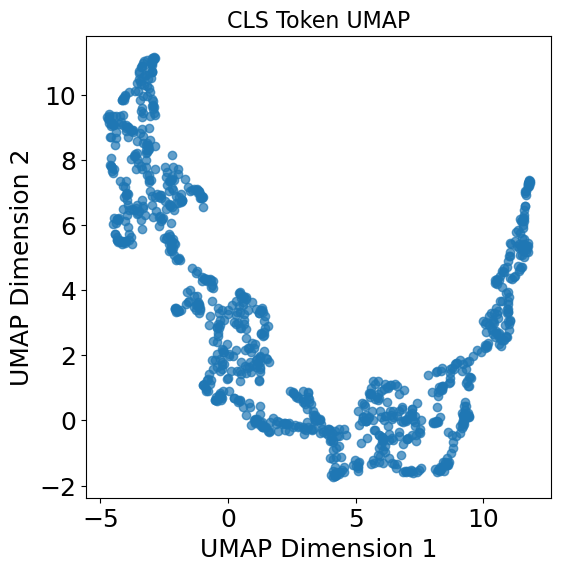

In [22]:
umap_visualize_CLS_tokens_no_labels(all_cls_tokens)

In [23]:
def umap_visualize_raw_data_no_labels(raw_data):
    # Apply UMAP
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(raw_data)

    # Plot
    plt.figure(figsize=(6, 6))
    plt.rcParams.update({'font.size': 18})
    sc = plt.scatter(embedding[:, 0].tolist(), embedding[:, 1].tolist(), alpha=0.7)
    plt.title("Raw Recordings UMAP\n({})".format(recording_col_name), fontsize=16)
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.savefig("inference_plots/umap_raw_data_uncolored.png", 
                facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close()

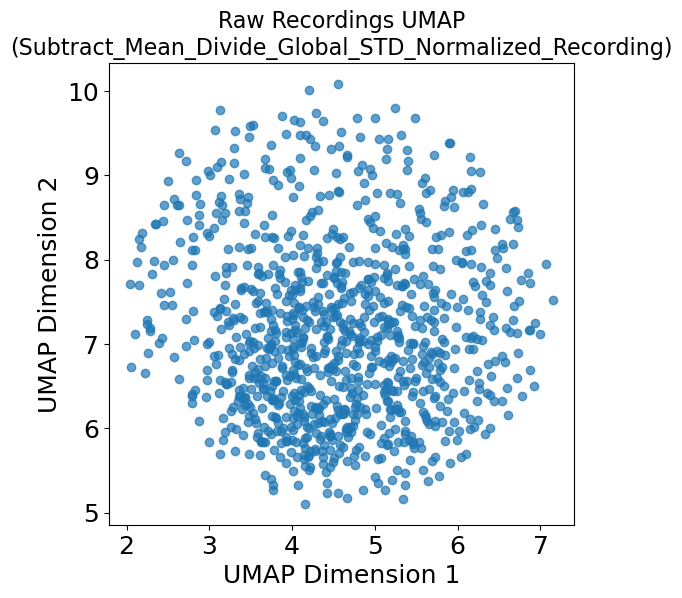

In [24]:
umap_visualize_raw_data_no_labels(raw_data=all_recordings)

In [25]:
concat_ds

Dataset({
    features: ['Raw_Recording', 'All_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_Per_Voxel_Normalized_Recording', 'Per_Voxel_All_Patient_Normalized_Recording', 'Subtract_Mean_Normalized_Recording', 'Subtract_Mean_Divide_Global_STD_Normalized_Recording', 'Subtract_Mean_Divide_Global_99thPercent_Normalized_Recording', 'Filename', 'Patient ID', 'Order', 'eid', 'Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity'],
    num_rows: 1000
})

In [26]:
concat_ds.features.keys()

dict_keys(['Raw_Recording', 'All_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_All_Voxel_Normalized_Recording', 'Per_Patient_Per_Voxel_Normalized_Recording', 'Per_Voxel_All_Patient_Normalized_Recording', 'Subtract_Mean_Normalized_Recording', 'Subtract_Mean_Divide_Global_STD_Normalized_Recording', 'Subtract_Mean_Divide_Global_99thPercent_Normalized_Recording', 'Filename', 'Patient ID', 'Order', 'eid', 'Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity'])

In [27]:
print(concat_ds["Gender"][:5])
print(concat_ds["Age.At.MHQ"][:5])
print(concat_ds["PHQ9.Severity"][:5])
print(concat_ds["Depressed.At.Baseline"][:5])
print(concat_ds["Neuroticism"][:5])
print(concat_ds["Self.Harm.Ever"][:5])
print(concat_ds["Not.Worth.Living"][:5])
print(concat_ds["PCL.Score"][:5])
print(concat_ds["GAD7.Severity"][:5])

[1.0, 1.0, 0.0, 0.0, 0.0]
[76.0, 61.0, 52.0, 55.0, 53.0]
[2.0, 0.0, 1.0, 13.0, 4.0]
[0.0, 0.0, 0.0, 1.0, 0.0]
[3.0, 4.0, 1.0, 6.0, 5.0]
[0.0, 0.0, 0.0, 1.0, 0.0]
[0.0, 0.0, 0.0, 1.0, 1.0]
[10.0, 4.0, 9.0, 14.0, 5.0]
[3.0, 0.0, 1.0, 5.0, 2.0]


In [28]:
def umap_visualize_CLS_tokens(cls_tokens, concat_ds, variable="Age.At.MHQ"):
    assert variable in concat_ds.features.keys(), \
    "Please specify a column in the dataset for variable of interest"
    variable_list = concat_ds[variable]
    var_name = variable.replace(".", "_")
    
    # Apply UMAP
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(cls_tokens)
    num_missing = sum([1 if math.isnan(num) else 0 for num in variable_list])

    # Plot
    plt.figure(figsize=(8, 6))
    plt.rcParams.update({'font.size': 18})
    sc = plt.scatter(embedding[:, 0].tolist(), embedding[:, 1].tolist(),
                     alpha=0.7, c=variable_list, plotnonfinite=False, cmap="viridis")  # , cmap=colormap
    plt.title("CLS Token UMAP Colored By {}\n({}/{} samples with missing\nvalues omitted)"
              .format(variable, num_missing, len(variable_list)), 
              fontsize=16)
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.colorbar(sc, label=variable)
    plt.savefig("inference_plots/umap_cls_tokens_{}_colored.png".format(var_name), 
                facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close()

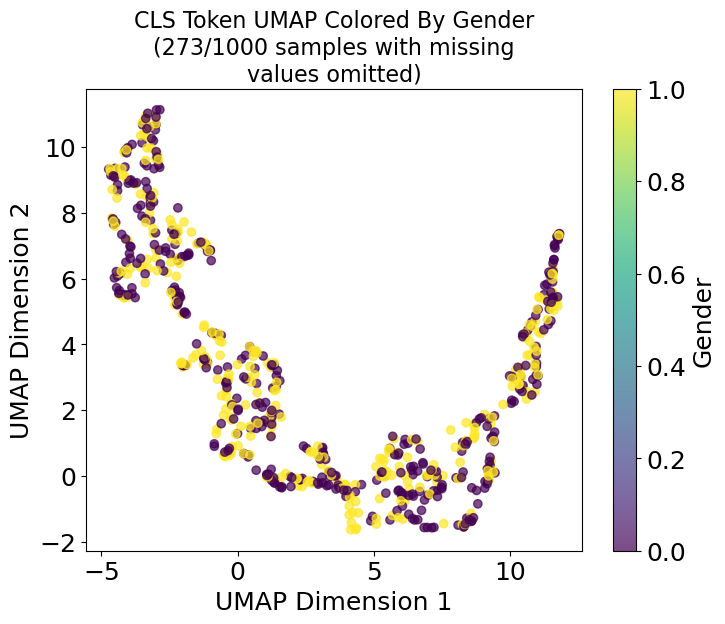

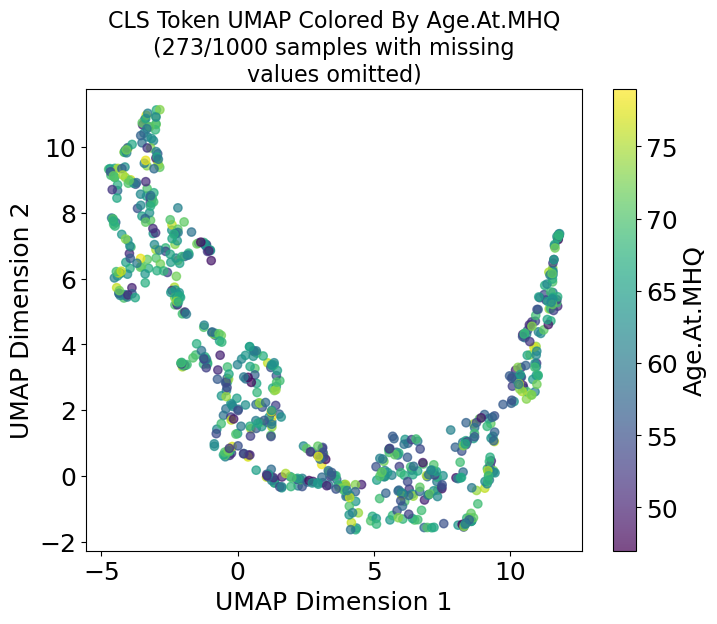

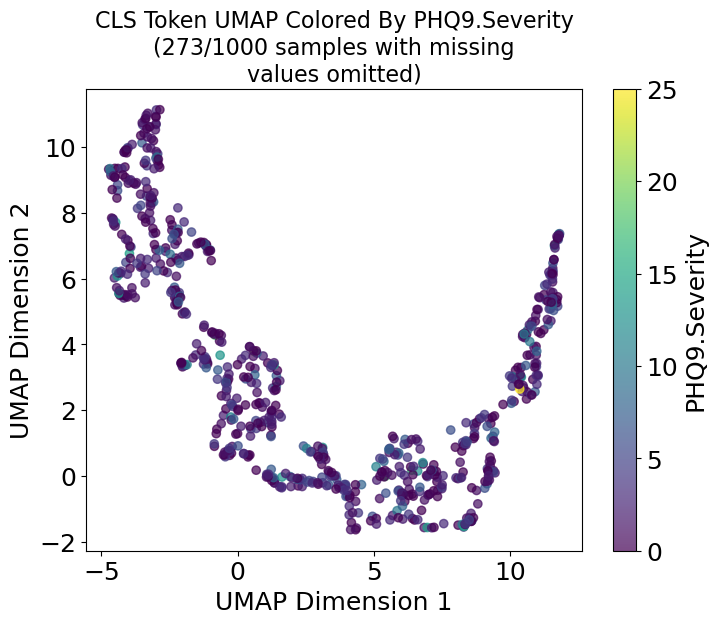

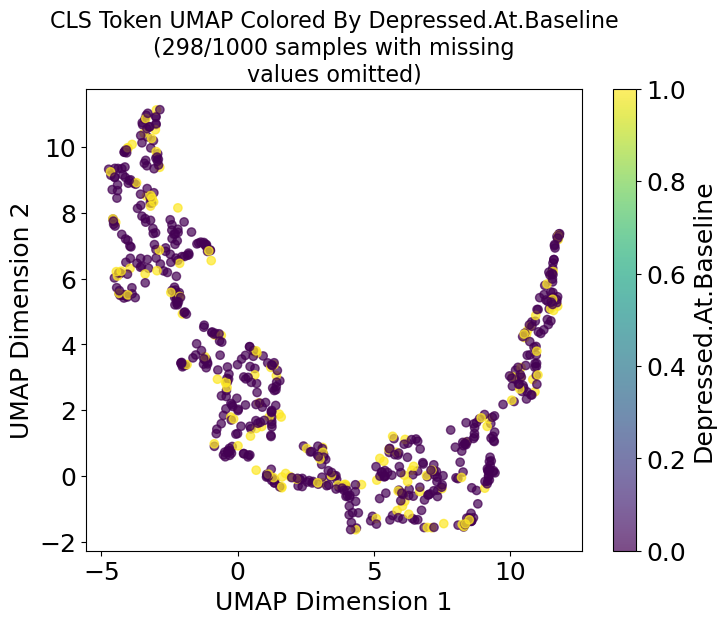

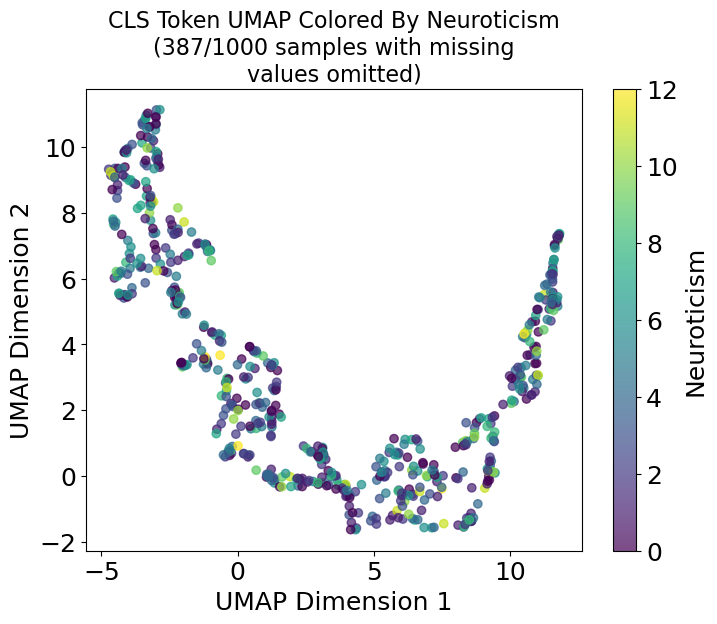

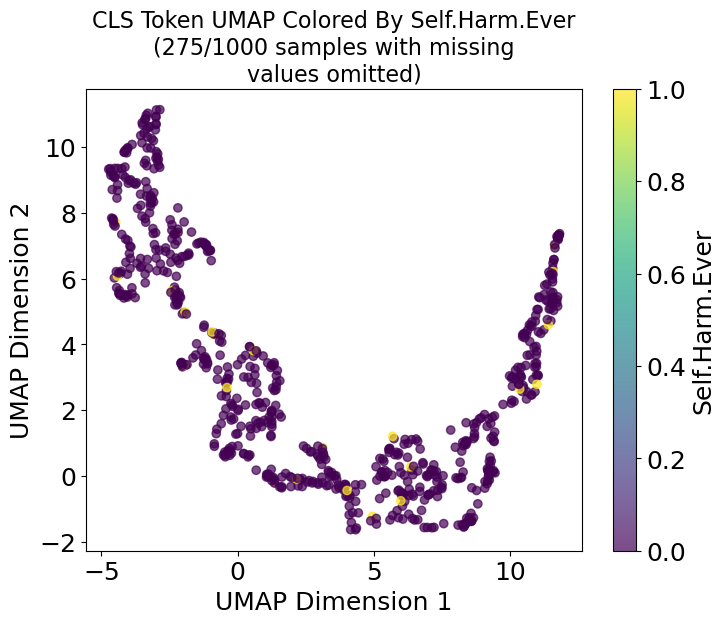

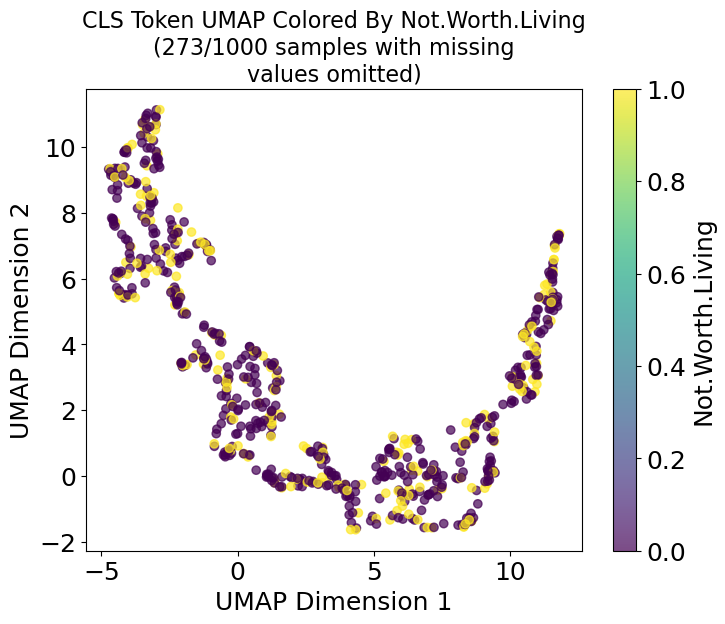

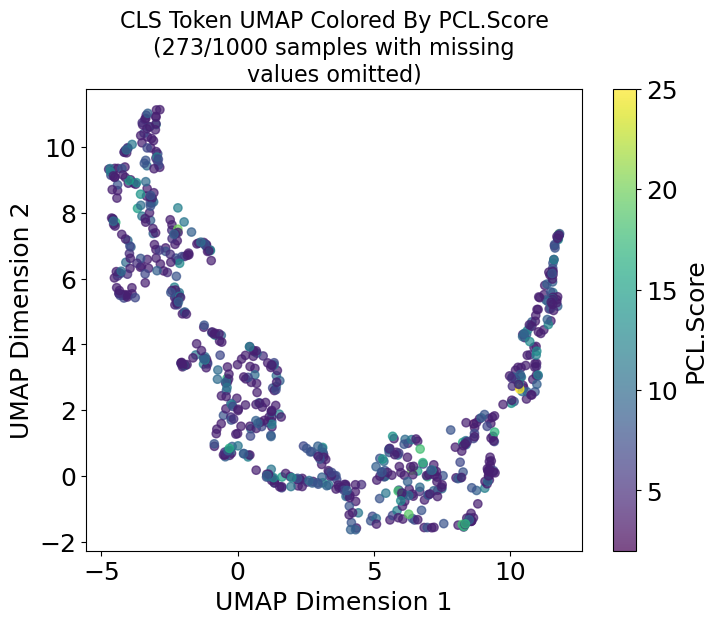

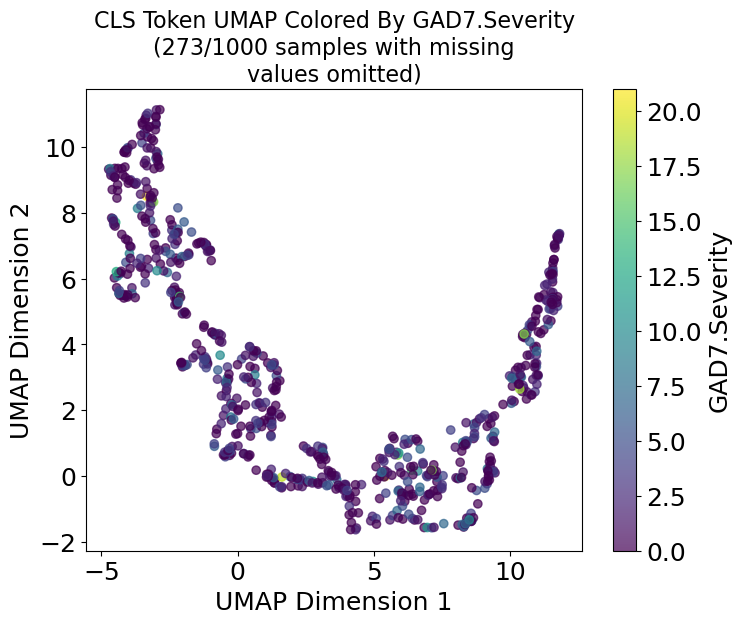

In [29]:
for variable_name in ['Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 
                      'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity']:
    umap_visualize_CLS_tokens(all_cls_tokens, concat_ds, variable=variable_name)

### Visualize raw data through UMAP

In [30]:
def umap_visualize_raw_data(raw_data, concat_ds, variable="Age.At.MHQ"):
    assert variable in concat_ds.features.keys(), \
    "Please specify a column in the dataset for variable of interest"
    variable_list = concat_ds[variable]
    var_name = variable.replace(".", "_")
    
    # Apply UMAP
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(raw_data)
    num_missing = sum([1 if math.isnan(num) else 0 for num in variable_list])

    # Plot
    plt.figure(figsize=(8, 6))
    plt.rcParams.update({'font.size': 18})
    sc = plt.scatter(embedding[:, 0].tolist(), embedding[:, 1].tolist(),
                     alpha=0.7, c=variable_list, plotnonfinite=False, cmap="viridis")  # , cmap=colormap
    plt.title("Raw Data UMAP Colored By {}\n({}/{} samples with missing\nvalues omitted)"
              .format(variable, num_missing, len(variable_list)), 
              fontsize=16)
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.colorbar(sc, label=variable)
    plt.savefig("inference_plots/umap_raw_data_{}_colored.png".format(var_name), 
                facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close()

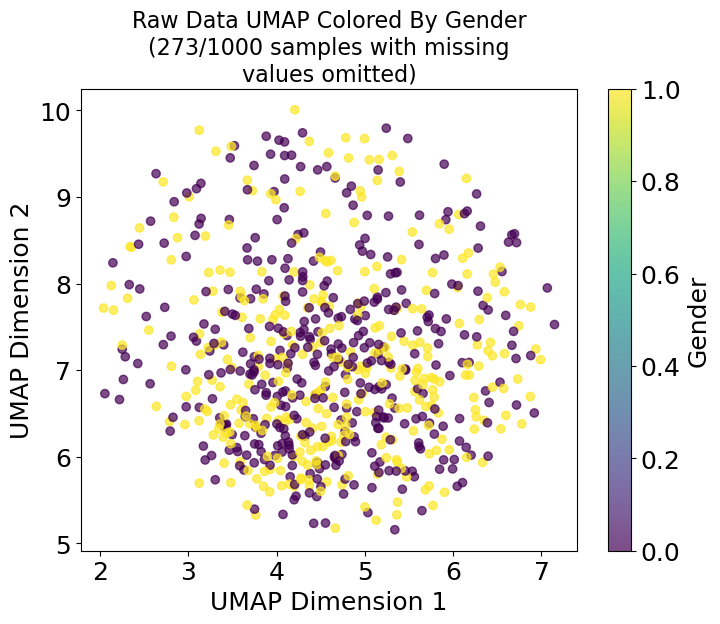

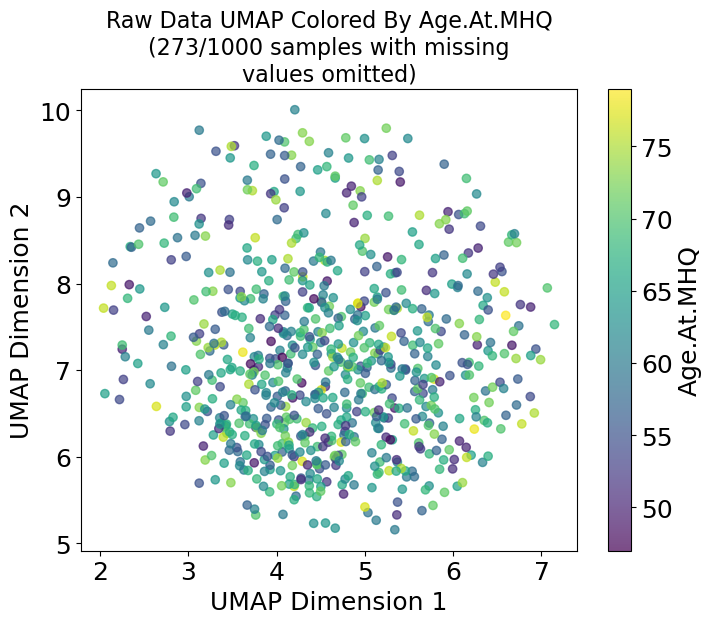

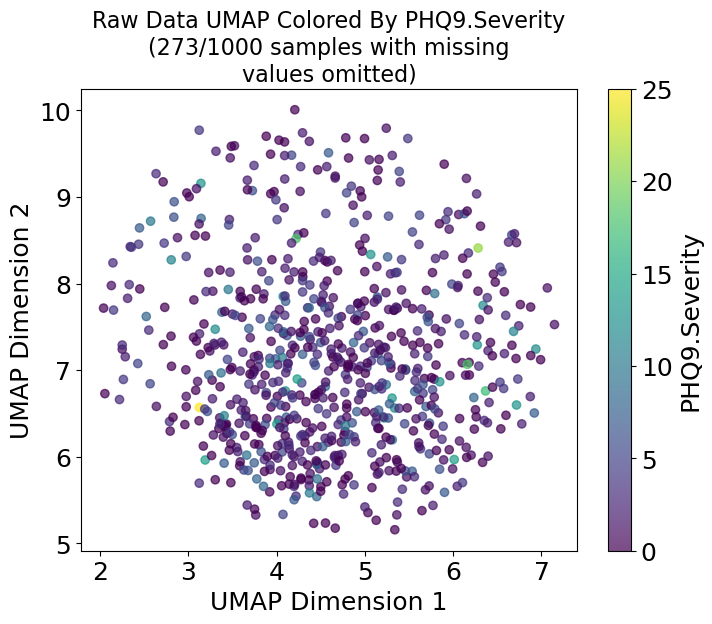

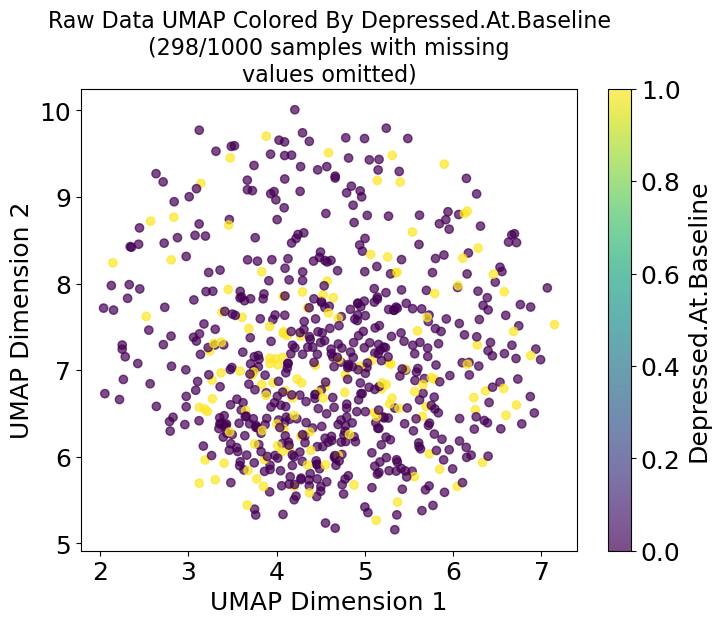

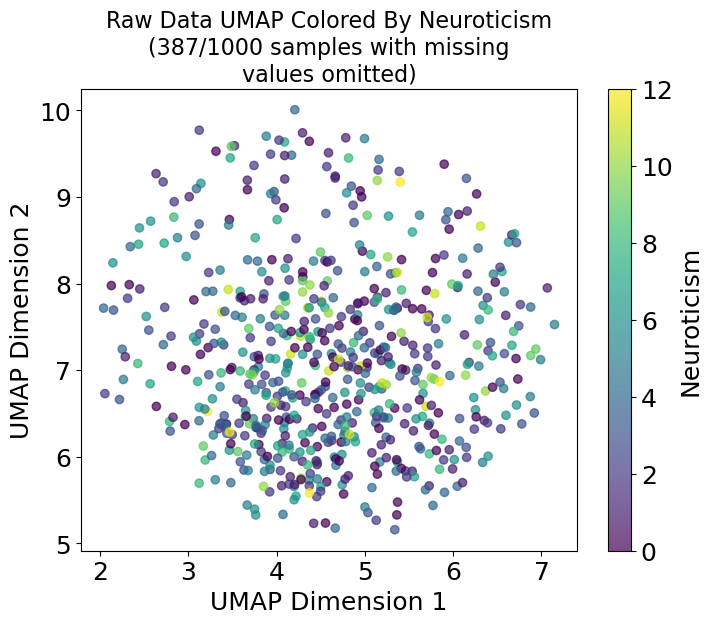

KeyboardInterrupt: 

In [31]:
for variable_name in ['Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 
                      'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity']:
    umap_visualize_raw_data(all_recordings, concat_ds, variable=variable_name)

# Perform PCA on CLS Tokens and Raw Recording

In [32]:
from sklearn.decomposition import PCA

In [33]:
print(all_cls_tokens.shape)
print(all_recordings.shape)

(1000, 512)
(1000, 207760)


In [34]:
n_components = 200
pca = PCA(n_components=n_components)

In [35]:
pca.fit(all_cls_tokens)

PCA(n_components=200)

In [36]:
print("pca.n_components_:", pca.n_components_)
print("pca.n_features_in_:", pca.n_features_in_)

pca.n_components_: 200
pca.n_features_in_: 512


In [37]:
print("pca.components_.shape:", pca.components_.shape)
print("pca.explained_variance_.shape:", pca.explained_variance_.shape)
print("pca.explained_variance_ratio_.shape:", pca.explained_variance_ratio_.shape)
print("pca.singular_values_.shape:", pca.singular_values_.shape)

pca.components_.shape: (200, 512)
pca.explained_variance_.shape: (200,)
pca.explained_variance_ratio_.shape: (200,)
pca.singular_values_.shape: (200,)


In [38]:
print(pca.explained_variance_[:10])
print(pca.explained_variance_ratio_[:10])
print(pca.explained_variance_ratio_.sum())

[3.5333530e+01 3.4154279e+00 1.9429535e+00 2.5473377e-01 1.2092981e-01
 2.7822362e-02 2.3885744e-02 1.5954951e-02 1.2512471e-02 8.0474652e-03]
[8.5796082e-01 8.2932651e-02 4.7178358e-02 6.1853882e-03 2.9363902e-03
 6.7557633e-04 5.7998823e-04 3.8741453e-04 3.0382499e-04 1.9540674e-04]
0.99999994


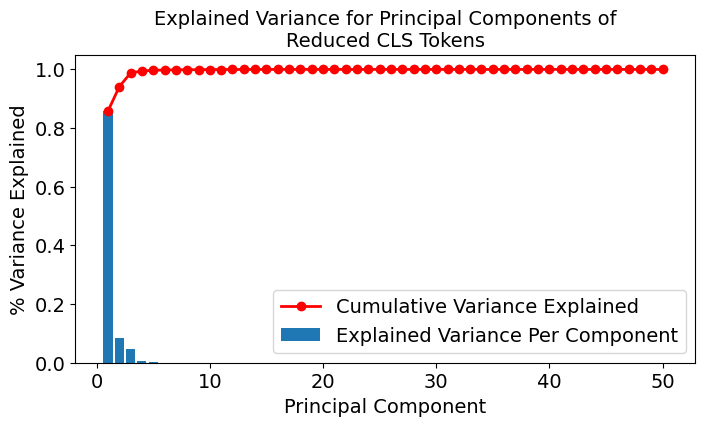

In [39]:
plt.figure(figsize=(8, 4))
pc_index = np.arange(50) + 1
plt.bar(pc_index, pca.explained_variance_ratio_[:50], label="Explained Variance Per Component")
plt.plot(pc_index, pca.explained_variance_ratio_[:50].cumsum(), 'o-', 
         linewidth=2, color='red', label="Cumulative Variance Explained")
plt.title('Explained Variance for Principal Components of\nReduced CLS Tokens', fontsize=14)
plt.xlabel('Principal Component', fontsize=14)
plt.ylabel('% Variance Explained', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.savefig("inference_plots/pca_scree_plot_cls_tokens_50components.png", bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

In [40]:
cls_tokens_pca_reduced = pca.transform(all_cls_tokens)
cls_tokens_pca_reduced.shape

(1000, 200)

In [41]:
np.save("inference_plots/pca_reduced_cls_tokens_200components.png", cls_tokens_pca_reduced)

Reduce raw data

In [42]:
n_components = 200
pca = PCA(n_components=n_components)

In [43]:
pca.fit(all_recordings)

PCA(n_components=200)

In [44]:
print("pca.n_components_:", pca.n_components_)
print("pca.n_features_in_:", pca.n_features_in_)

pca.n_components_: 200
pca.n_features_in_: 207760


In [45]:
print("pca.components_.shape:", pca.components_.shape)
print("pca.explained_variance_.shape:", pca.explained_variance_.shape)
print("pca.explained_variance_ratio_.shape:", pca.explained_variance_ratio_.shape)
print("pca.singular_values_.shape:", pca.singular_values_.shape)

pca.components_.shape: (200, 207760)
pca.explained_variance_.shape: (200,)
pca.explained_variance_ratio_.shape: (200,)
pca.singular_values_.shape: (200,)


In [46]:
print(pca.explained_variance_[:10])
print(pca.explained_variance_ratio_[:10])
print(pca.explained_variance_ratio_.sum())

[965.30695 892.5333  881.0527  859.5356  834.8619  822.1021  814.50397
 799.138   779.4612  777.20557]
[0.0046471  0.00429676 0.00424149 0.00413791 0.00401912 0.0039577
 0.00392112 0.00384714 0.00375242 0.00374156]
0.37258953


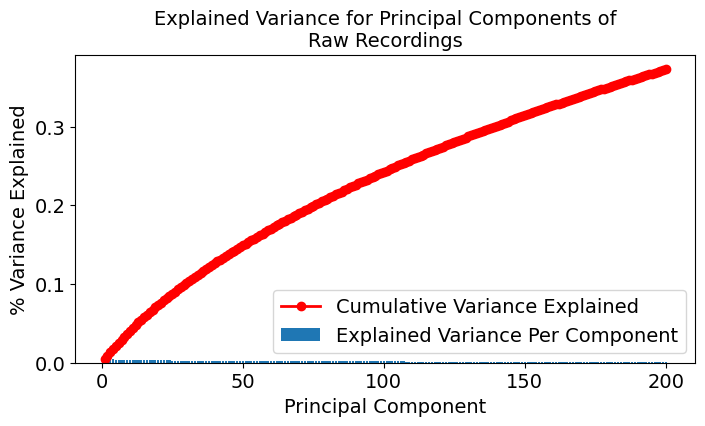

In [47]:
plt.figure(figsize=(8, 4))
pc_index = np.arange(200) + 1
plt.bar(pc_index, pca.explained_variance_ratio_, label="Explained Variance Per Component")
plt.plot(pc_index, pca.explained_variance_ratio_.cumsum(), 'o-', markersize=6,
         linewidth=2, color='red', label="Cumulative Variance Explained")
plt.title('Explained Variance for Principal Components of\nRaw Recordings', fontsize=14)
plt.xlabel('Principal Component', fontsize=14)
plt.ylabel('% Variance Explained', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.savefig("inference_plots/pca_scree_plot_raw_data_490len_200components.png", bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

In [48]:
raw_data_pca_reduced = pca.transform(all_recordings)
print(raw_data_pca_reduced.shape)
print(raw_data_pca_reduced[:, :50].shape)

(1000, 200)
(1000, 50)


In [49]:
np.save("inference_plots/pca_reduced_raw_data_490len_200components.png", raw_data_pca_reduced)

In [56]:
raw_data_pca_reduced_10components = raw_data_pca_reduced[:, :10]
cls_tokens_pca_reduced_10_components = cls_tokens_pca_reduced[:, :10]

In [57]:
print(raw_data_pca_reduced_10components.shape)
print(cls_tokens_pca_reduced_10_components.shape)

(1000, 10)
(1000, 10)


# Plotting CLS Tokens and Raw Recordings With PCA

In [58]:
def pca_visualize_CLS_tokens(cls_token_pca_reduction, concat_ds, variable="Age.At.MHQ"):
    assert variable in concat_ds.features.keys(), \
    "Please specify a column in the dataset for variable of interest"
    variable_list = concat_ds[variable]
    var_name = variable.replace(".", "_")
    num_missing = sum([1 if math.isnan(num) else 0 for num in variable_list])

    # Plot
    plt.figure(figsize=(8, 6))
    plt.rcParams.update({'font.size': 18})
    sc = plt.scatter(cls_token_pca_reduction[:, 0].tolist(), cls_token_pca_reduction[:, 1].tolist(),
                     alpha=0.7, c=variable_list, plotnonfinite=False, cmap='viridis')
    plt.title("CLS Token First Two Principal Components\nColored By {} ({}/{} samples\nwith missing values omitted)"
              .format(variable, num_missing, len(variable_list)), 
              fontsize=16)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(sc, label=variable)
    plt.savefig("inference_plots/pca_cls_tokens_{}_colored.png".format(var_name), 
                facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close()

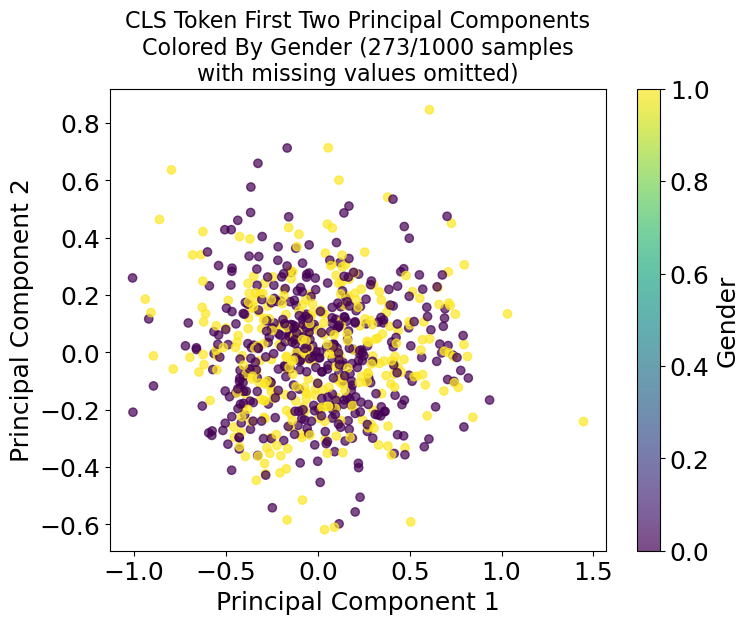

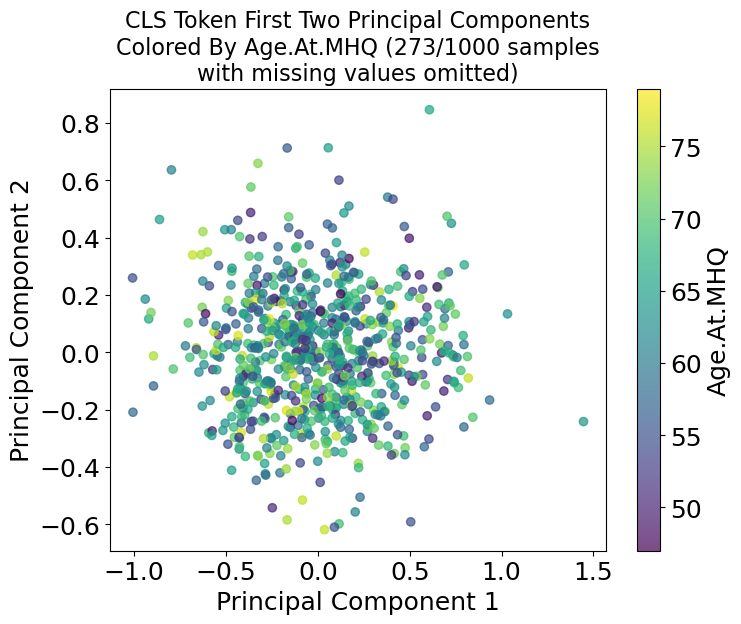

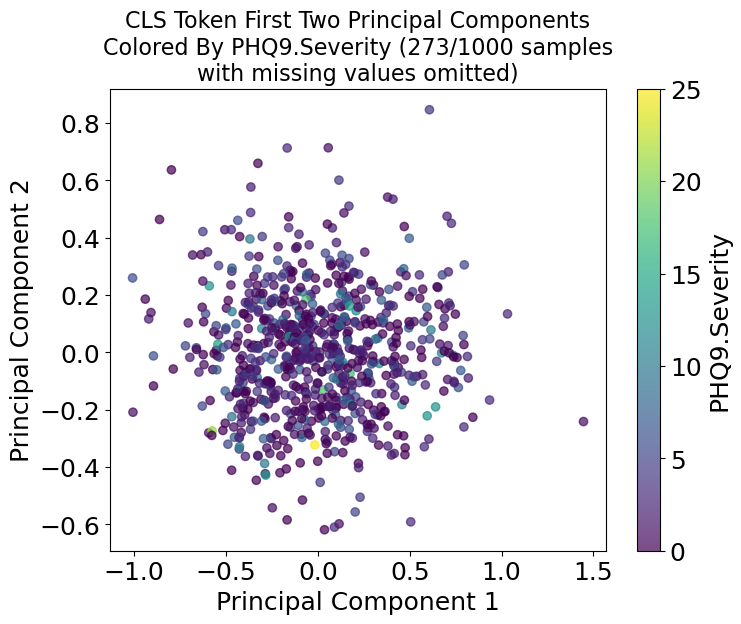

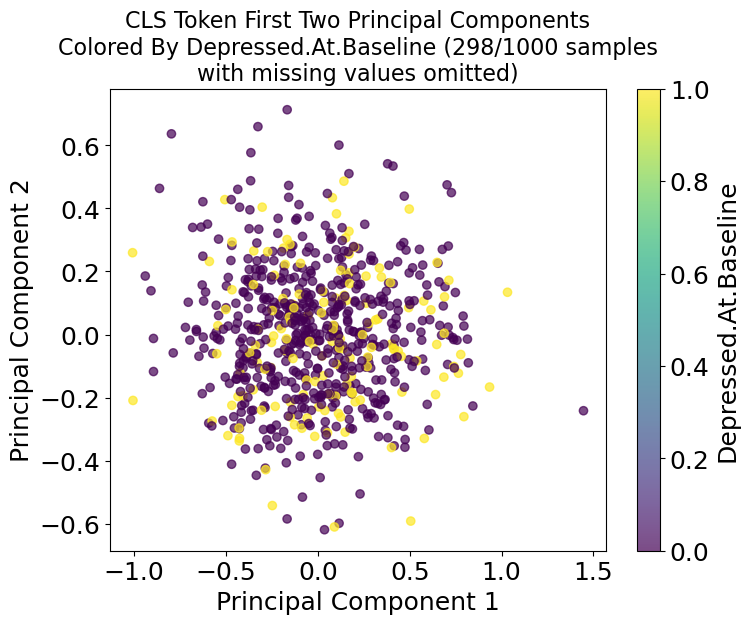

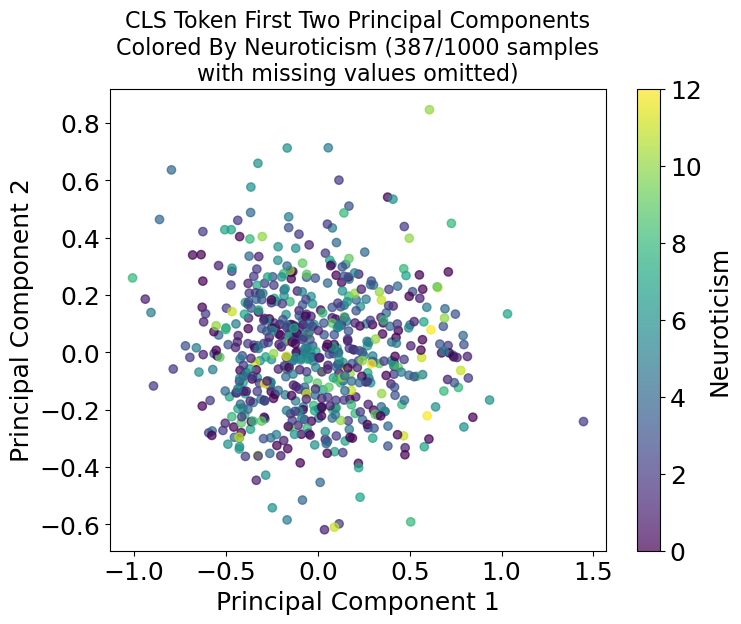

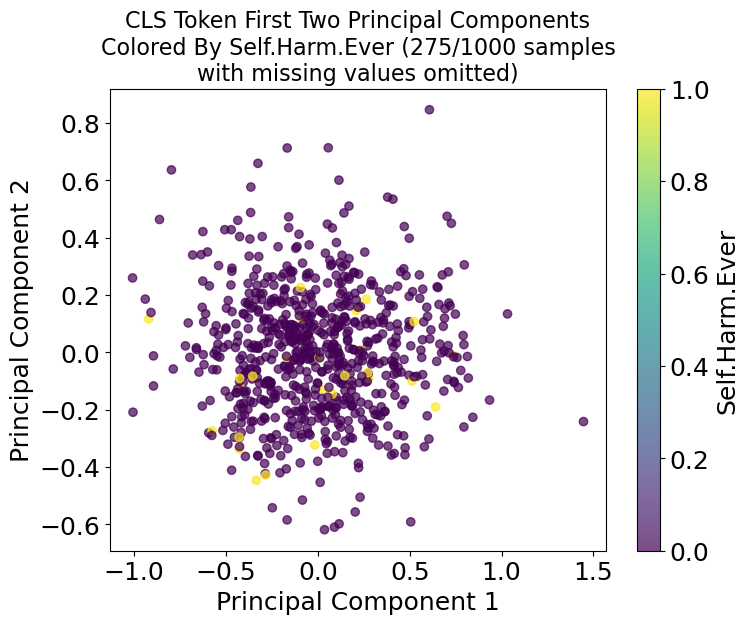

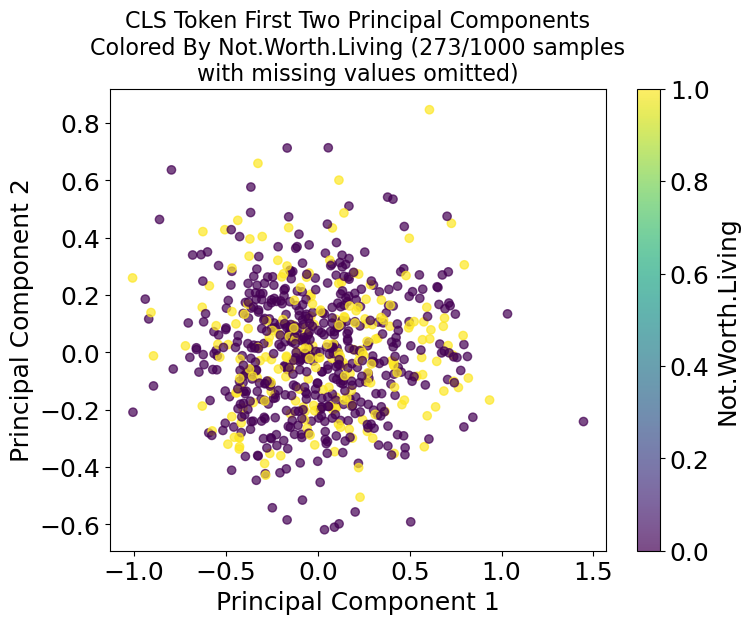

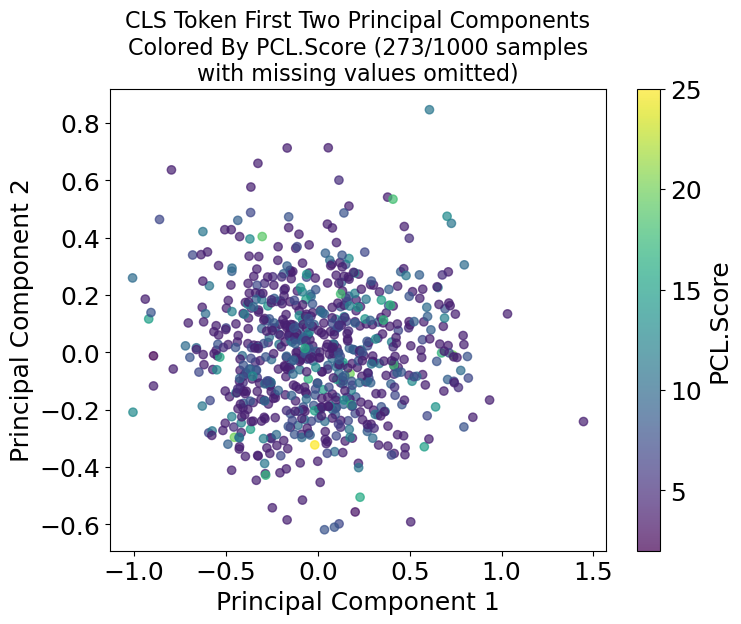

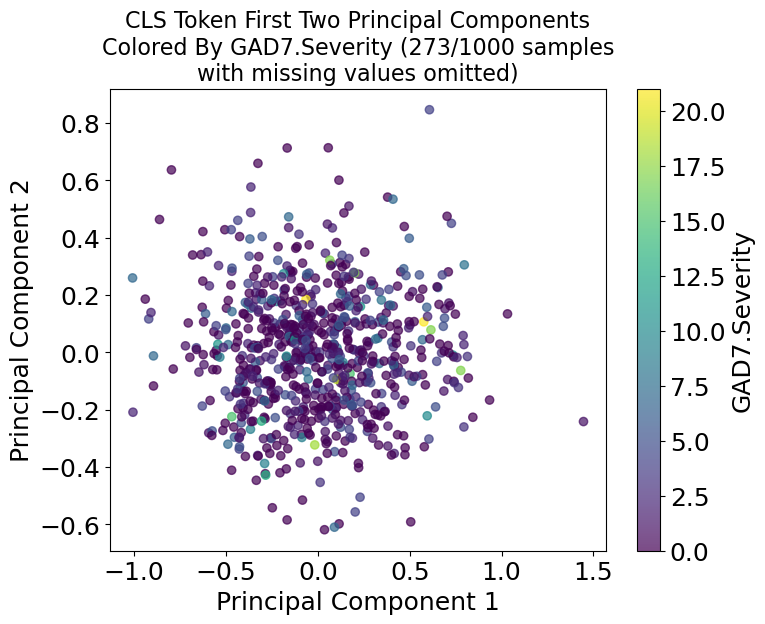

In [59]:
for variable_name in ['Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 
                      'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity']:
    pca_visualize_CLS_tokens(cls_tokens_pca_reduced_10_components, concat_ds, variable=variable_name)

In [60]:
def pca_visualize_raw_data(raw_data_pca_reduction, concat_ds, variable="Age.At.MHQ"):
    assert variable in concat_ds.features.keys(), \
    "Please specify a column in the dataset for variable of interest"
    variable_list = concat_ds[variable]
    var_name = variable.replace(".", "_")
    num_missing = sum([1 if math.isnan(num) else 0 for num in variable_list])

    # Plot
    plt.figure(figsize=(8, 6))
    plt.rcParams.update({'font.size': 18})
    sc = plt.scatter(raw_data_pca_reduction[:, 0].tolist(), raw_data_pca_reduction[:, 1].tolist(),
                     alpha=0.7, c=variable_list, plotnonfinite=False, cmap='viridis')
    plt.title("Raw Recording First Two Principal Components\nColored By {} ({}/{} samples\nwith missing values omitted)"
              .format(variable, num_missing, len(variable_list)), 
              fontsize=16)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(sc, label=variable)
    plt.savefig("inference_plots/pca_raw_data_{}_colored.png".format(var_name), 
                facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close()

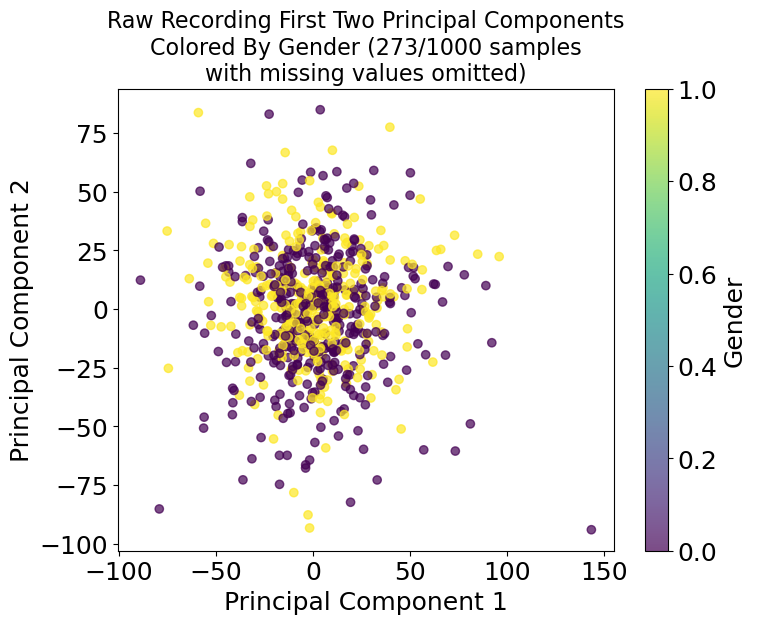

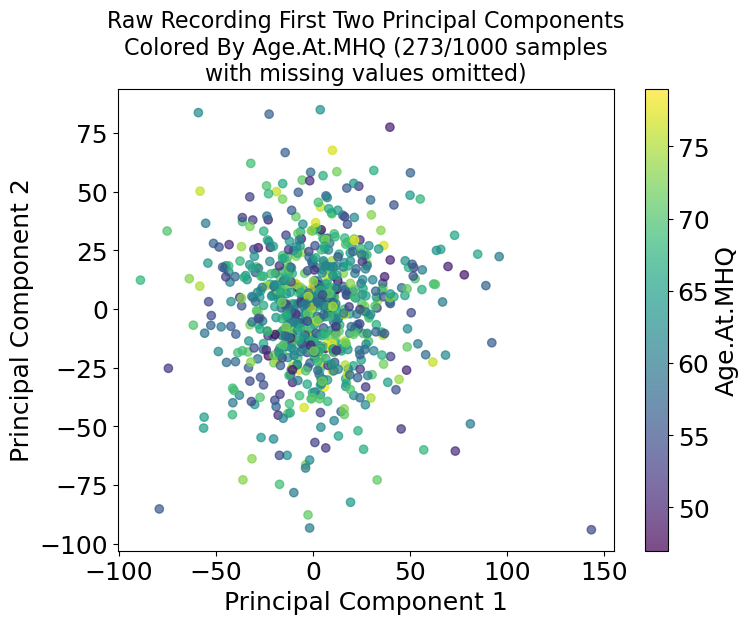

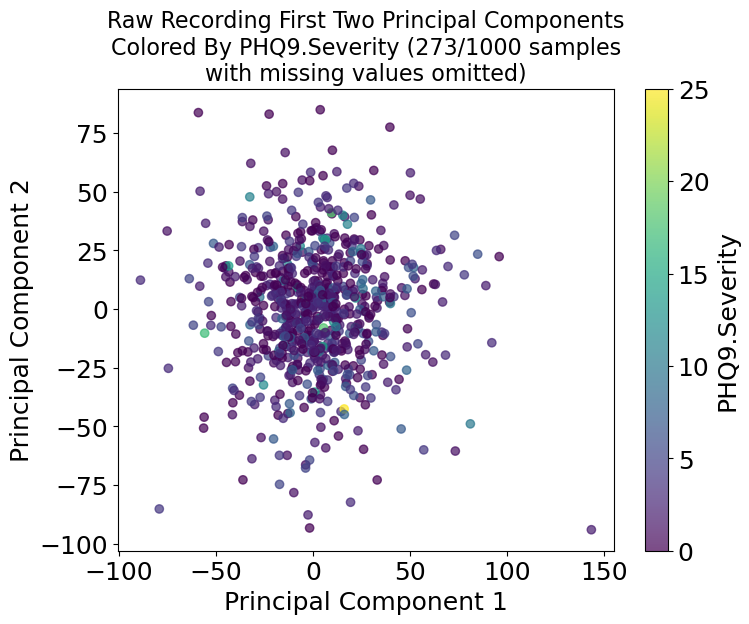

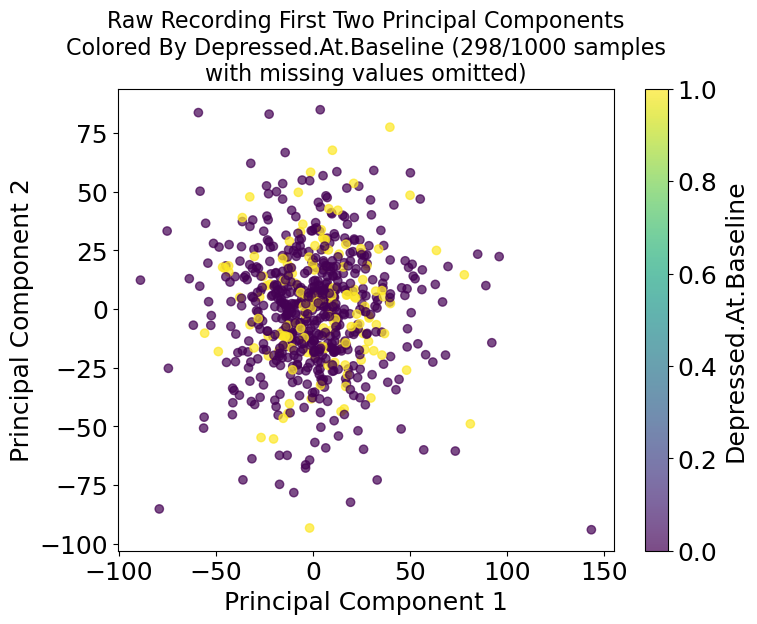

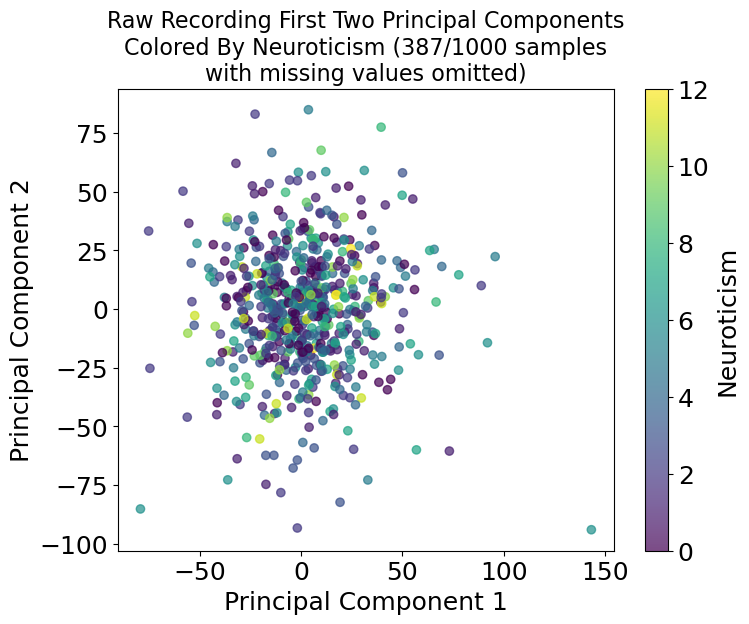

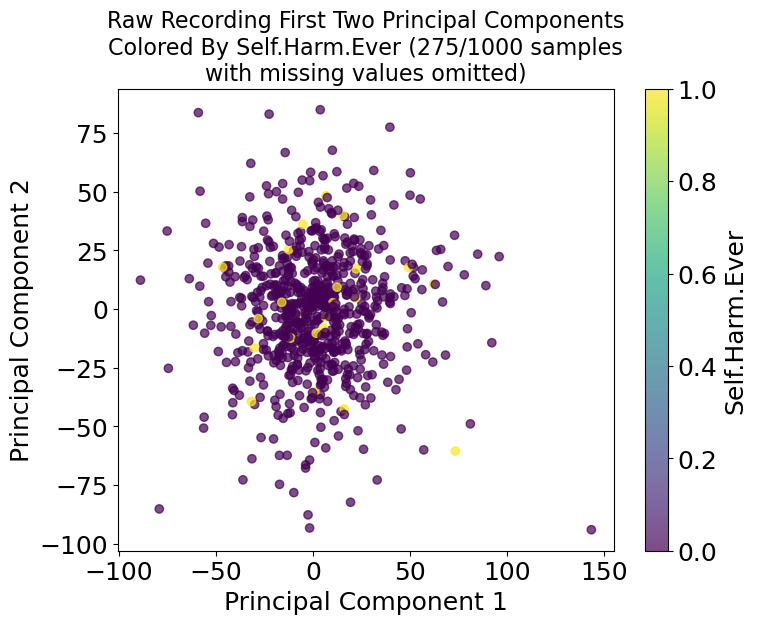

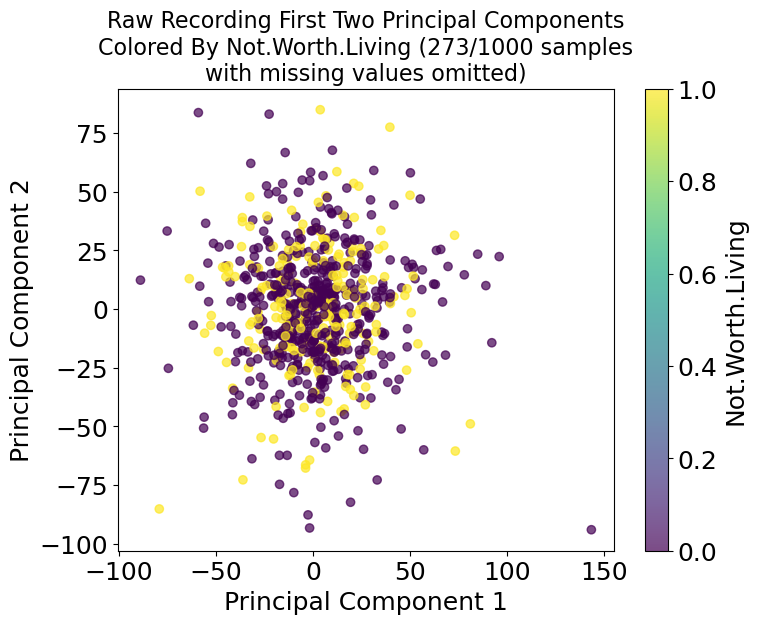

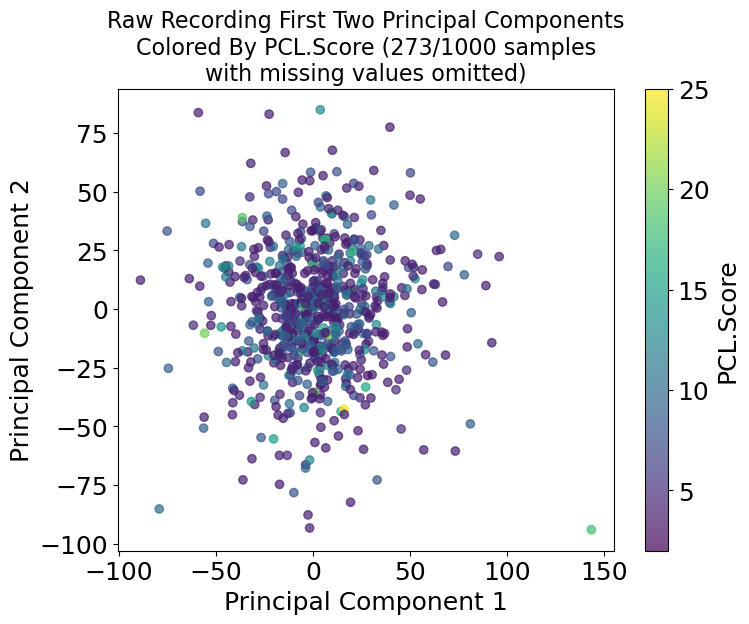

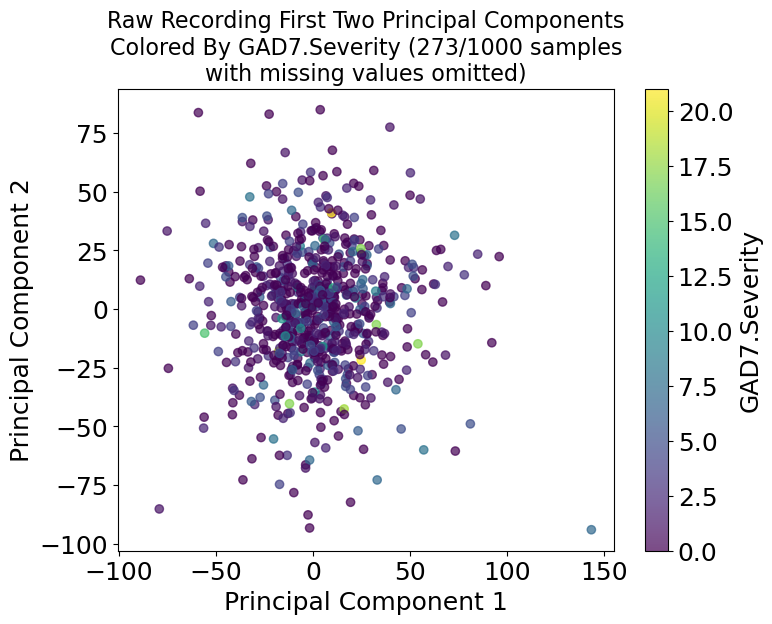

In [61]:
for variable_name in ['Gender', 'Age.At.MHQ', 'PHQ9.Severity', 'Depressed.At.Baseline', 'Neuroticism', 
                      'Self.Harm.Ever', 'Not.Worth.Living', 'PCL.Score', 'GAD7.Severity']:
    pca_visualize_raw_data(raw_data_pca_reduced_10components, concat_ds, variable=variable_name)